In [90]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np
import glob

In [91]:
import pandas as pd
import numpy as np
import glob

def calculate_time_series_stats(file_pattern, stride=500):
    files = glob.glob(file_pattern)
    if not files:
        print(f"No files found for pattern: {file_pattern}")
        return None
    
    drift_runs = []
    difficulty_runs = []
    hashrate_runs = []
    
    # Pre-allocate array structures for log states
    log_difficulty_runs = []
    log_hashrate_runs = []
    
    time_axis = None
    target_length = None
    
    type_spec = {
        'timestamp': np.float64,
        'difficulty': np.float64,
        'skew': np.float64,
        'real_hash_rate': np.float64
    }
    
    for f in files:
        try:
            df_iterator = pd.read_csv(
                f, 
                usecols=['timestamp', 'difficulty', 'skew', 'real_hash_rate'], 
                dtype=type_spec,
                engine='c',
                low_memory=False
            )
        except Exception as e:
            print(f"Skipping broken file {f}: {e}")
            continue
            
        df_iterator.columns = df_iterator.columns.str.strip()
        df_sub = df_iterator.iloc[::stride].copy().dropna()
        
        # Extracted metrics matching your specific units (Drift scaled to days)
        drift_data = df_sub['skew'].values * 14.0
        diff_data = df_sub['difficulty'].values
        hash_data = df_sub['real_hash_rate'].values
        
        # Calculate safe log10 arrays identical to your C++ data-frame casts
        log_diff_data = np.log10(np.maximum(diff_data.astype(float), 1e-10))
        log_hash_data = np.log10(np.maximum(hash_data.astype(float), 1e-10))
        
        if target_length is None:
            target_length = len(drift_data)
            shifted_timestamps = df_sub['timestamp'].values - 62168450400
            time_axis = pd.to_datetime(shifted_timestamps, unit='s')
            
        if len(drift_data) > target_length:
            drift_data = drift_data[:target_length]
            diff_data = diff_data[:target_length]
            hash_data = hash_data[:target_length]
            log_diff_data = log_diff_data[:target_length]
            log_hash_data = log_hash_data[:target_length]
        elif len(drift_data) < target_length:
            missing_count = target_length - len(drift_data)
            if missing_count < (target_length * 0.05): 
                drift_data = np.pad(drift_data, (0, missing_count), 'edge')
                diff_data = np.pad(diff_data, (0, missing_count), 'edge')
                hash_data = np.pad(hash_data, (0, missing_count), 'edge')
                log_diff_data = np.pad(log_diff_data, (0, missing_count), 'edge')
                log_hash_data = np.pad(log_hash_data, (0, missing_count), 'edge')
            else:
                continue

        drift_runs.append(drift_data)
        difficulty_runs.append(diff_data)
        hashrate_runs.append(hash_data)
        log_difficulty_runs.append(log_diff_data)
        log_hashrate_runs.append(log_hash_data)
        
    N = len(drift_runs)
    if N == 0: return None
    
    # Convert all collectors to clean numpy arrays
    drift_m = np.array(drift_runs, dtype=np.float64)
    diff_m  = np.array(difficulty_runs, dtype=np.float64)
    hash_m  = np.array(hashrate_runs, dtype=np.float64)
    ldiff_m = np.array(log_difficulty_runs, dtype=np.float64)
    lhash_m = np.array(log_hashrate_runs, dtype=np.float64)
    
    # Helper to clean up statistical dictionary returns
    def get_stats(matrix):
        mean = np.mean(matrix, axis=0)
        std = np.std(matrix, axis=0, ddof=1)
        ci = 1.96 * (std / np.sqrt(N))
        return mean, ci

    m_drift, ci_drift = get_stats(drift_m)
    m_diff,  ci_diff  = get_stats(diff_m)
    m_hash,  ci_hash  = get_stats(hash_m)
    m_ldiff, ci_ldiff = get_stats(ldiff_m)
    m_lhash, ci_lhash = get_stats(lhash_m)
        
    return {
        'time': time_axis[:target_length],
        'mean_drift': m_drift, 'ci_drift': ci_drift,
        'mean_diff': m_diff,   'ci_diff': ci_diff,
        'mean_hash': m_hash,   'ci_hash': ci_hash,
        'mean_ldiff': m_ldiff, 'ci_ldiff': ci_ldiff,
        'mean_lhash': m_lhash, 'ci_lhash': ci_lhash
    }

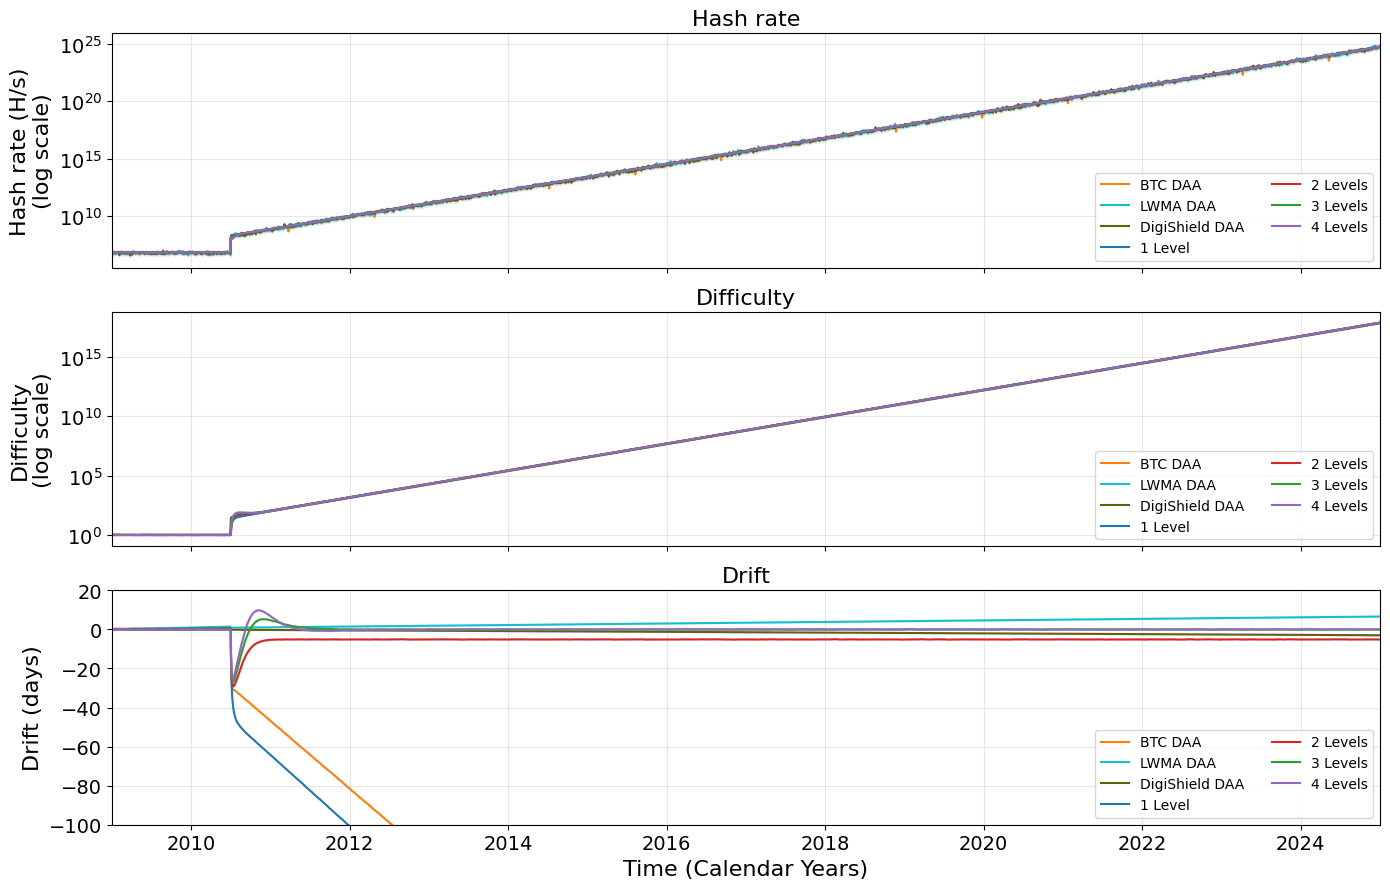

In [92]:
# ==================== MASTER CONTROLS ====================
use_log = True  # Toggle True for Logarithmic scales, False for Linear scales
# =========================================================

# 1. Gather all statistical data
stats_1_level = calculate_time_series_stats("data/multirun/adaptiveExpJump/layers_1_run_*.csv", stride=500)
stats_2_level = calculate_time_series_stats("data/multirun/adaptiveExpJump/layers_2_run_*.csv", stride=500)
stats_3_level = calculate_time_series_stats("data/multirun/adaptiveExpJump/layers_3_run_*.csv", stride=500)
stats_4_level = calculate_time_series_stats("data/multirun/adaptiveExpJump/layers_4_run_*.csv", stride=500)
stats_btc        = calculate_time_series_stats("data/multirun/adaptiveExpJump/btc_run_*.csv", stride=500)
stats_lwma       = calculate_time_series_stats("data/multirun/adaptiveExpJump/lwma_run_*.csv", stride=500)
stats_digishield = calculate_time_series_stats("data/multirun/adaptiveExpJump/digishield_run_*.csv", stride=500)

# 2. Setup the Workspace with 3 subplots sharing the X-axis
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Main drawing sequence order: Benchmarks in back, Multi-layers up front
configs = [
    (stats_btc,        'BTC DAA',        '#ff7f0e'),  # Bitcoin Orange
    (stats_lwma,       'LWMA DAA',       '#17becf'),  # Cyan
    (stats_digishield, 'DigiShield DAA', '#606010'),  # Slate Grey
    (stats_1_level,   '1 Level',        '#1f77b4'),  # Blue
    (stats_2_level,   '2 Levels',       '#d62728'),  # Red
    (stats_3_level,   '3 Levels',       '#2ca02c'),  # Green
    (stats_4_level,   '4 Levels',       '#9467bd')   # Purple
]

# 3. Render Curves and Shaded 95% Confidence Intervals
for stats, label, color in configs:
    if stats is None: continue
    
    # --- PANEL 1: HASH RATE ---
    if use_log:
        ax1.plot(stats['time'], stats['mean_lhash'], label=label, color=color, linewidth=1.5)
        ax1.fill_between(stats['time'], stats['mean_lhash'] - stats['ci_lhash'], stats['mean_lhash'] + stats['ci_lhash'], color=color, alpha=0.10)
    else:
        ax1.plot(stats['time'], stats['mean_hash'], label=label, color=color, linewidth=1.5)
        ax1.fill_between(stats['time'], stats['mean_hash'] - stats['ci_hash'], stats['mean_hash'] + stats['ci_hash'], color=color, alpha=0.10)

    # --- PANEL 2: DIFFICULTY ---
    if use_log:
        ax2.plot(stats['time'], stats['mean_ldiff'], label=label, color=color, linewidth=1.5)
        ax2.fill_between(stats['time'], stats['mean_ldiff'] - stats['ci_ldiff'], stats['mean_ldiff'] + stats['ci_ldiff'], color=color, alpha=0.10)
    else:
        ax2.plot(stats['time'], stats['mean_diff'], label=label, color=color, linewidth=1.5)
        ax2.fill_between(stats['time'], stats['mean_diff'] - stats['ci_diff'], stats['mean_diff'] + stats['ci_diff'], color=color, alpha=0.10)

    # --- PANEL 3: ACCUMULATED DRIFT (Always Linear Days) ---
    ax3.plot(stats['time'], stats['mean_drift'], label=label, color=color, linewidth=1.5)
    ax3.fill_between(stats['time'], stats['mean_drift'] - stats['ci_drift'], stats['mean_drift'] + stats['ci_drift'], color=color, alpha=0.10)

# Set clean date boundaries for all panels
start_date = pd.Timestamp('2009-01-01')
end_date = pd.Timestamp('2025-01-01')
ax1.set_xlim(start_date, end_date)

# --- Format Subplot 1: Hash Rate ---
if use_log:
    ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter("$10^{{{x:.0f}}}$"))
    ax1.set_ylabel('Hash rate (H/s)\n(log scale)', fontsize=16)
else:
    ax1.set_ylabel('Hash rate (H/s)', fontsize=16)
ax1.set_title('Hash rate', fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right', ncol=2)

# --- Format Subplot 2: Difficulty ---
if use_log:
    ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter("$10^{{{x:.0f}}}$"))
    ax2.set_ylabel('Difficulty\n(log scale)', fontsize=16)
else:
    ax2.set_ylabel('Difficulty', fontsize=16)
ax2.set_title('Difficulty', fontsize=16)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower right', ncol=2)

# --- Format Subplot 3: Network Drift ---
ax3.set_title('Drift', fontsize=16)
ax3.set_xlabel('Time (Calendar Years)', fontsize=16)
ax3.set_ylabel('Drift (days)', fontsize=16)
ax3.set_ylim(-100, 20)  # Preserving your exact target zoom window boundaries
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.grid(True, alpha=0.3)
ax3.legend(loc='lower right', ncol=2)
ax3.set_ylim(-100, 20)

plt.subplots_adjust(hspace=0.4)
plt.tight_layout()
plt.show()

In [93]:
for stats, label, _ in configs:
    if stats is None: continue
    final_mean_days = stats['mean_drift'][-1]
    final_ci_days = stats['ci_drift'][-1]
    print(f"{label} Final Drift Baseline: {final_mean_days:.4f} +/- {final_ci_days:.4f} Days")

BTC DAA Final Drift Baseline: -532.7803 +/- 0.1298 Days
LWMA DAA Final Drift Baseline: 6.6245 +/- 0.0568 Days
DigiShield DAA Final Drift Baseline: -2.9697 +/- 0.0198 Days
1 Level Final Drift Baseline: -575.2386 +/- 0.0881 Days
2 Levels Final Drift Baseline: -5.1432 +/- 0.0676 Days
3 Levels Final Drift Baseline: 0.0457 +/- 0.0688 Days
4 Levels Final Drift Baseline: 0.0194 +/- 0.0630 Days


Non-adaptive step hash function:
- BTC DAA Final Drift Baseline: -27.7392 +/- 0.1673 Days
- LWMA DAA Final Drift Baseline: 14.9019 +/- 0.0507 Days
- DigiShield DAA Final Drift Baseline: 5.4468 +/- 0.0162 Days
- 1 Level Final Drift Baseline: -47.3261 +/- 0.0683 Days
- 2 Levels Final Drift Baseline: -0.0032 +/- 0.0827 Days
- 3 Levels Final Drift Baseline: -0.0559 +/- 0.0974 Days
- 4 Levels Final Drift Baseline: -0.0274 +/- 0.0950 Days

Adaptive step hash function
- BTC DAA Final Drift Baseline: -27.6980 +/- 0.1808 Days
- LWMA DAA Final Drift Baseline: 14.8932 +/- 0.0559 Days
- DigiShield DAA Final Drift Baseline: 5.4255 +/- 0.0141 Days
- 1 Level Final Drift Baseline: -47.3322 +/- 0.1029 Days
- 2 Levels Final Drift Baseline: 0.0359 +/- 0.0631 Days
- 3 Levels Final Drift Baseline: -0.0935 +/- 0.0616 Days
- 4 Levels Final Drift Baseline: 0.0322 +/- 0.0852 Days

Non-adaptive exp hash function with jump
- BTC DAA Final Drift Baseline: -532.8880 +/- 0.1543 Days
- LWMA DAA Final Drift Baseline: 6.7068 +/- 0.0567 Days
- DigiShield DAA Final Drift Baseline: -2.9714 +/- 0.0142 Days
- 1 Level Final Drift Baseline: -575.3501 +/- 0.0821 Days
- 2 Levels Final Drift Baseline: -5.1174 +/- 0.0720 Days
- 3 Levels Final Drift Baseline: -0.0139 +/- 0.0568 Days
- 4 Levels Final Drift Baseline: 0.0598 +/- 0.0971 Days

Adaptive exp hash function with jump
- BTC DAA Final Drift Baseline: -532.7803 +/- 0.1298 Days
- LWMA DAA Final Drift Baseline: 6.6245 +/- 0.0568 Days
- DigiShield DAA Final Drift Baseline: -2.9697 +/- 0.0198 Days
- 1 Level Final Drift Baseline: -575.2386 +/- 0.0881 Days
- 2 Levels Final Drift Baseline: -5.1432 +/- 0.0676 Days
- 3 Levels Final Drift Baseline: 0.0457 +/- 0.0688 Days
- 4 Levels Final Drift Baseline: 0.0194 +/- 0.0630 Days